# Я художник, я так вижу, визуализация данных в питоне

# I. Numpy

### Импортируйте NumPy

In [318]:
import numpy as np


### Создайте одномерный массив размера 10, заполненный нулями и пятым элемент равным 1. Трансформируйте в двумерный массив.

In [319]:
arr = np.zeros(10).astype(int)
arr
arr[4] = 1
arr1 = arr.reshape(2,-1)
print(arr1)

[[0 0 0 0 1]
 [0 0 0 0 0]]


### Создайте одномерный массив со значениями от 10 до 49 и разверните его (первый элемент становится последним). Найдите в нем все четные элементы.

In [320]:
arr = np.arange(10,50)[::-1]
print(arr)
even_arr = arr[arr % 2 == 0]
print(even_arr)

[49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26
 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10]
[48 46 44 42 40 38 36 34 32 30 28 26 24 22 20 18 16 14 12 10]


### Создайте двумерный массив 3x3 со значениями от 0 до 8

In [321]:
arr = np.arange(0,9).reshape(3,3)
print(arr)

[[0 1 2]
 [3 4 5]
 [6 7 8]]


### Создайте массив 4x3x2 со случайными значениями. Найти его минимум и максимум.

In [322]:
np.random.seed(42)
arr = np.random.random((4, 3, 2))

maximum = np.max(arr)
minimum = np.min(arr)
print(f"maximum: {maximum}")
print(f"minimum: {minimum}")

maximum: 0.9699098521619943
minimum: 0.020584494295802447


### Создайте два двумерных массива размерами 6x4 и 4x3 и произведите их матричное умножение. 

In [323]:
np.random.seed(42)
arr1 = np.random.randint(0, 100, size=(6,4))
arr2 = np.random.randint(0, 100, size=(4,3))
arr3 = np.dot(arr1, arr2)
print(arr3)




[[11285 16922 13506]
 [17546 16090 14536]
 [20761 22949 19158]
 [ 7400  6187  6376]
 [ 7836 11596  8345]
 [ 8485 10221  7080]]


### Создайте случайный двумерный массив 7x7, найти у него среднее и стандартное оклонение. Нормализуйте этот массив.

In [324]:
np.random.seed(42)
arr = np.random.randint(0,100, (7,7))
print(arr)
mean = np.mean(arr)
print(mean)
std = np.std(arr)
print(std)
z_score = (arr - mean) / std
print(z_score)

[[51 92 14 71 60 20 82]
 [86 74 74 87 99 23  2]
 [21 52  1 87 29 37  1]
 [63 59 20 32 75 57 21]
 [88 48 90 58 41 91 59]
 [79 14 61 61 46 61 50]
 [54 63  2 50  6 20 72]]
51.10204081632653
28.071515738111984
[[-0.00363503  1.45692023 -1.3216971   0.70883095  0.31697466 -1.1079573
   1.10068724]
 [ 1.24318044  0.81570085  0.81570085  1.27880374  1.70628332 -1.0010874
  -1.74917668]
 [-1.072334    0.03198827 -1.78479998  1.27880374 -0.78734761 -0.50236122
  -1.78479998]
 [ 0.42384456  0.28135136 -1.1079573  -0.68047771  0.85132415  0.21010476
  -1.072334  ]
 [ 1.31442703 -0.11050493  1.38567363  0.24572806 -0.35986802  1.42129693
   0.28135136]
 [ 0.99381734 -1.3216971   0.35259796  0.35259796 -0.18175153  0.35259796
  -0.03925833]
 [ 0.10323487  0.42384456 -1.74917668 -0.03925833 -1.60668349 -1.1079573
   0.74445425]]


# II. Pandas

### Импортируйте: pandas, matplotlib, seaborn

In [325]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import ssl
import urllib.request
import seaborn as sns

### Загрузите датасет Tips из набора датасетов seaborn

In [326]:
# Настраиваем SSL для urllib (который использует seaborn)
ssl_context = ssl.create_default_context()
ssl_context.check_hostname = False
ssl_context.verify_mode = ssl.CERT_NONE

# Применяем настройки
urllib.request.install_opener(
    urllib.request.build_opener(
        urllib.request.HTTPSHandler(context=ssl_context)
    )
)

# Загружаем датасет
tips = sns.load_dataset('tips')

### Посмотрите на первые 5 строчек

In [327]:
print(tips.head(5))

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


### Узнайте сколько всего строчек и колонок в данных

In [328]:
rows,columns = tips.shape
print(f"строк: {rows}")
print(f"колонок: {columns}")

строк: 244
колонок: 7


### Проверьте есть ли пропуски в данных

In [329]:
print(f"Количество пропусков: {tips.isnull().sum().sum()}")


Количество пропусков: 0


### Посмотрите на распределение числовых признаков

In [330]:
numeric_cols = tips.select_dtypes(include=['float64', 'int64']).columns
print(f"Числовые признаки(колонки) ({len(numeric_cols)}): {list(numeric_cols)}")

print("\nРаспределение:")
print(tips[numeric_cols].describe().round(3))

Числовые признаки(колонки) (3): ['total_bill', 'tip', 'size']

Распределение:
       total_bill      tip     size
count     244.000  244.000  244.000
mean       19.786    2.998    2.570
std         8.902    1.384    0.951
min         3.070    1.000    1.000
25%        13.348    2.000    2.000
50%        17.795    2.900    2.000
75%        24.127    3.562    3.000
max        50.810   10.000    6.000


### Найдите максимальное значение 'total_bill'

In [331]:
print(f"Максимум в total_bill: {tips['total_bill'].max()}")

Максимум в total_bill: 50.81


### Найдите количество курящих людей

In [332]:
print(tips[tips['smoker'] == 'Yes'].shape[0])



93


### Узнайте какой средний 'total_bill' в зависимости от 'day'

In [333]:
print(tips.groupby('day',observed=True)['total_bill'].mean().round(2))



day
Thur    17.68
Fri     17.15
Sat     20.44
Sun     21.41
Name: total_bill, dtype: float64


### Отберите строчки с 'total_bill' больше медианы и узнайте какой средний 'tip' в зависимости от 'sex'

In [334]:
median_bill = tips['total_bill'].median()
print(median_bill)
high_bill_tips = tips[tips['total_bill'] > median_bill]
print(high_bill_tips)
avg_tip_by_sex = high_bill_tips.groupby('sex', observed=True)['tip'].mean().round(2)
print(avg_tip_by_sex)

17.795
     total_bill   tip     sex smoker   day    time  size
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
5         25.29  4.71    Male     No   Sun  Dinner     4
7         26.88  3.12    Male     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[122 rows x 7 columns]
sex
Male      3.76
Female    3.66
Name: tip, dtype: float64


### Преобразуйте признак 'smoker' в бинарный (0-No, 1-Yes)

In [335]:
tips_copy1 = tips.copy()
# print(tips_copy1['smoker'])
tips_copy1['smoker_binary_values'] = tips_copy1['smoker'].map({'No': 0, 'Yes': 1})
print(tips_copy1['smoker_binary_values'])

0      0
1      0
2      0
3      0
4      0
      ..
239    0
240    1
241    1
242    0
243    0
Name: smoker_binary_values, Length: 244, dtype: category
Categories (2, int64): [1, 0]


# III. Visualization

### Постройте гистограмму распределения признака 'total_bill'

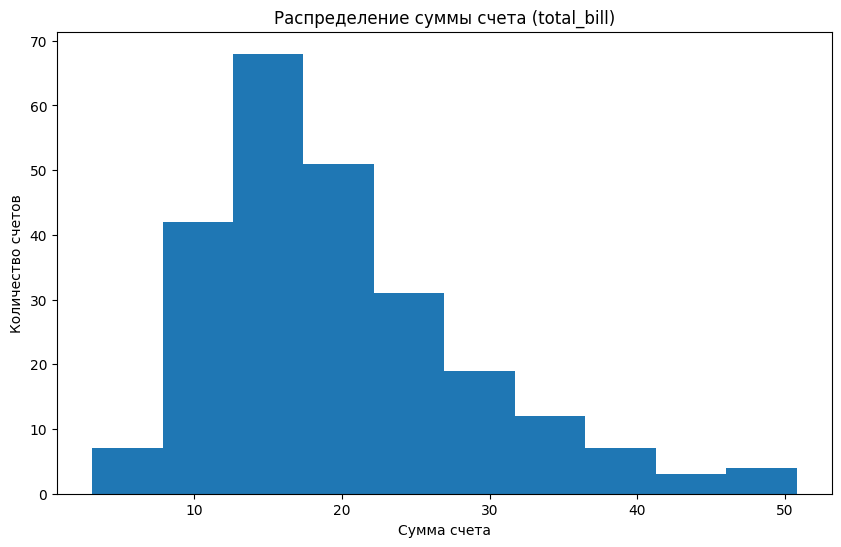

In [336]:
# Создаем фигуру и оси
plt.figure(figsize=(10, 6))

# Строим простейшую гистограмму
plt.hist(tips['total_bill'])

# Добавляем заголовки и подписи
plt.title('Распределение суммы счета (total_bill)')
plt.xlabel('Сумма счета')
plt.ylabel('Количество счетов')

plt.show()

### Постройте scatterplot, представляющий взаимосвязь между признаками 'total_bill' и 'tip'

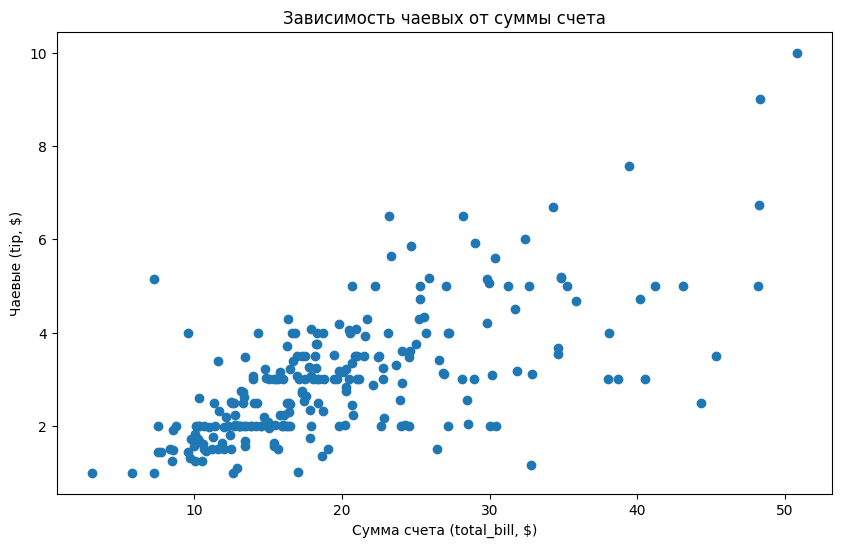

In [337]:
# Создаем фигуру
plt.figure(figsize=(10, 6))

# Строим простейший scatterplot
plt.scatter(tips['total_bill'], tips['tip'])

# Добавляем подписи
plt.title('Зависимость чаевых от суммы счета')
plt.xlabel('Сумма счета (total_bill, $)')
plt.ylabel('Чаевые (tip, $)')

# Показываем график
plt.show()

### Постройте pairplot

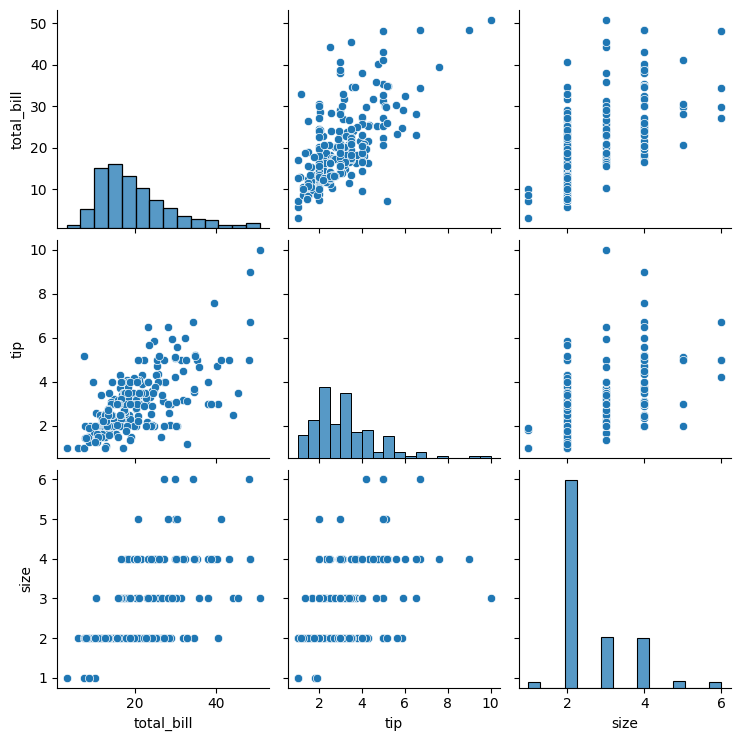

In [338]:
sns.pairplot(tips)
plt.show()

### Постройте график взаимосвязи между признаками 'total_bill' и 'day'

<Axes: xlabel='day', ylabel='total_bill'>

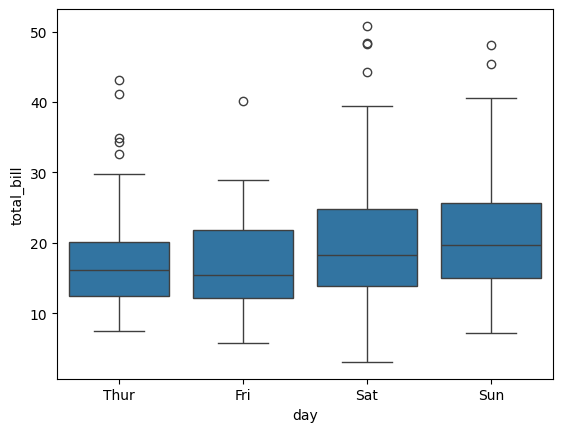

In [339]:
sns.boxplot(x='day', y='total_bill', data=tips)

### Постройте две гистограммы распределения признака 'tip' в зависимости от категорий 'time'

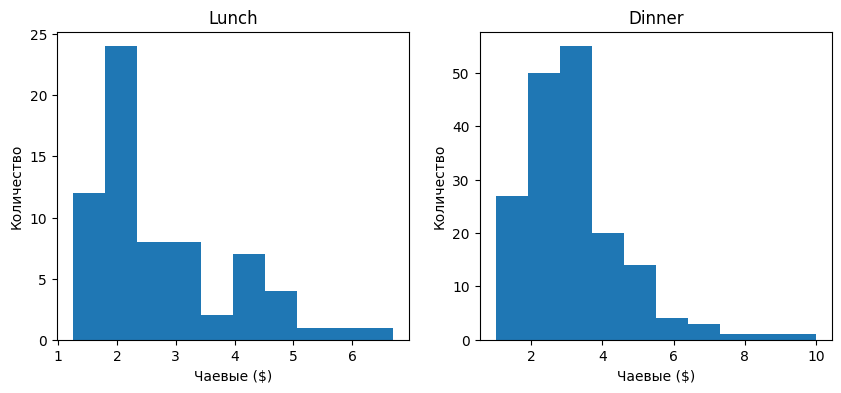

In [340]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.set_title('Lunch')
ax1.hist(tips[tips['time'] == 'Lunch']['tip'])
ax1.set_xlabel('Чаевые ($)'); ax1.set_ylabel('Количество')

ax2.set_title('Dinner')
ax2.hist(tips[tips['time'] == 'Dinner']['tip'])
ax2.set_xlabel('Чаевые ($)'); ax2.set_ylabel('Количество')

plt.show()

### Постройте два графика scatterplot, представляющих взаимосвязь между признаками 'total_bill' и 'tip' один для Male, другой для Female и раскрасьте точки в зависимоти от признака 'smoker'

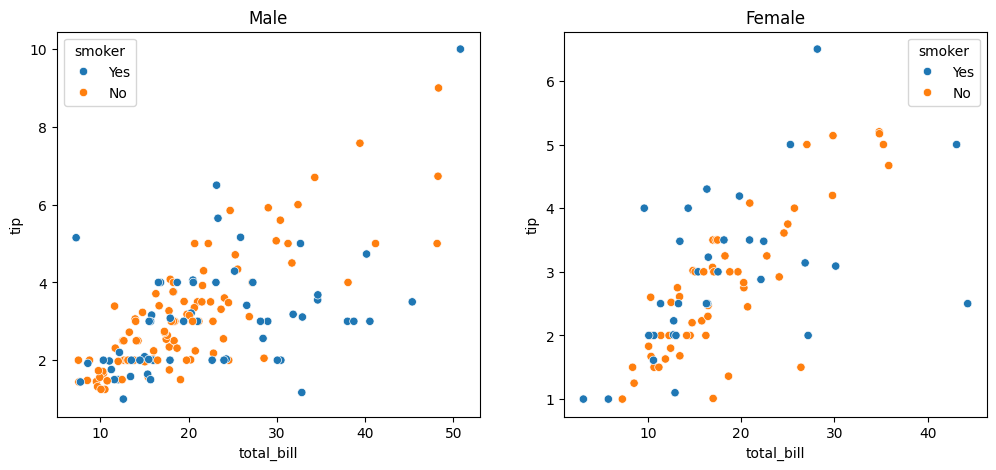

In [341]:
male_data = tips[tips['sex'] == 'Male']
female_data = tips[tips['sex'] == 'Female']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=male_data, x='total_bill', y='tip', hue='smoker', ax=axes[0])
axes[0].set_title('Male')
sns.scatterplot(data=female_data, x='total_bill', y='tip', hue='smoker', ax=axes[1])
axes[1].set_title('Female')
plt.show()

## Сделайте выводы по анализу датасета и построенным графикам. По желанию можете продолжить анализ данных и также отразить это в выводах.

In [342]:
# 1) Наибольшее количество счетов небольшие по сумме
# 2) Есть линейная зависомость размера чаевых от суммы счета, больше счет - больше чаевые
# 3) Наиболее крупные счета в выходные
# 4) Во вреия ужина больше клиентов и чаевых
# 5) Мужчины оставляют более высокие чаевые
# 6) Курящие мужчины немного более склонны к большим счетам
# 7) В целом, курение практически не влияет на чаевые